In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [40]:
df = pd.read_csv("15_Investment Analytics.csv")
df.head()

,deal,description,episode,category,entrepreneurs,location,website,askedfor,exchangeforstake,valuation,season,shark1,shark2,shark3,shark4,shark5,title,episode_season,multiple_entreprenuers
0,False,Bluetooth device implant for your ear.,1,Novelties,Darrin Johnson,"St. Paul, MN",NaN,1000000,15,6666667,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Ionic Ear,1-1,False
1,True,Retail and wholesale pie factory with two reta...,1,Specialty Food,Tod Wilson,"Somerset, NJ",http://whybake.com/,460000,10,4600000,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Mr. Tod's Pie Factory,1-1,False
2,True,Ava the Elephant is a godsend for frazzled par...,1,Baby and Child Care,Tiffany Krumins,"Atlanta, GA",http://www.avatheelephant.com/,50000,15,333333,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Ava the Elephant,1-1,False
3,False,"Organizing, packing, and moving services deliv...",1,Consumer Services,"Nick Friedman, Omar Soliman","Tampa, FL",http://collegehunkshaulingjunk.com/,250000,25,1000000,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,College Foxes Packing Boxes,1-1,False
4,False,Interactive media centers for healthcare waiti...,1,Consumer Services,Kevin Flannery,"Cary, NC",http://www.wispots.com/,1200000,10,12000000,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Wispots,1-1,False


## Dataset Overview

 

- Each row represents a startup pitch

- Key columns:

  - deal → Whether deal happened (TRUE/FALSE)

  - askfor → Asking amount

  - valuation → Company valuation

  - category → Business category

In [41]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   deal                    495 non-null    bool 
 1   description             495 non-null    str  
 2   episode                 495 non-null    int64
 3   category                495 non-null    str  
 4   entrepreneurs           423 non-null    str  
 5   location                495 non-null    str  
 6   website                 456 non-null    str  
 7   askedfor                495 non-null    int64
 8   exchangeforstake        495 non-null    int64
 9   valuation               495 non-null    int64
 10  season                  495 non-null    int64
 11  shark1                  495 non-null    str  
 12  shark2                  495 non-null    str  
 13  shark3                  495 non-null    str  
 14  shark4                  495 non-null    str  
 15  shark5                  495 non-nu

,episode,askedfor,exchangeforstake,valuation,season
count,495.000000,4.950000e+02,495.000000,4.950000e+02,495.000000
mean,12.125253,2.584909e+05,17.539394,2.165615e+06,4.048485
std,7.918133,4.615999e+05,10.061047,3.761971e+06,1.658518
min,1.000000,1.000000e+04,3.000000,4.000000e+04,1.000000
25%,5.000000,7.500000e+04,10.000000,4.400000e+05,3.000000
50%,11.000000,1.500000e+05,15.000000,1.000000e+06,4.000000
75%,18.000000,2.500000e+05,20.000000,2.000000e+06,5.000000
max,29.000000,5.000000e+06,100.000000,3.000000e+07,6.000000


In [42]:
# Convert deal column to numeric

df['deal'] = df['deal'].map({'TRUE': 1, 'FALSE': 0})

# Handle missing values

df = df.dropna()

df.head()

,deal,description,episode,category,entrepreneurs,location,website,askedfor,exchangeforstake,valuation,season,shark1,shark2,shark3,shark4,shark5,title,episode_season,multiple_entreprenuers


## Data Cleaning

 

- Converted deal column into numeric (1 = success, 0 = failure)

- Removed missing values to ensure accurate analysis

In [43]:
print(df.columns)

Index(['deal', 'description', 'episode', 'category', 'entrepreneurs',
       'location', 'website', 'askedfor', 'exchangeforstake', 'valuation',
       'season', 'shark1', 'shark2', 'shark3', 'shark4', 'shark5', 'title',
       'episode_season', 'multiple_entreprenuers'],
      dtype='str')


##  fEATURE ENGINEERING

In [49]:
# Create new feature: investment ratio
df['investment_ratio'] = df['askedfor'] / df['valuation']

df.head()

,deal,description,episode,category,entrepreneurs,location,website,askedfor,exchangeforstake,valuation,season,shark1,shark2,shark3,shark4,shark5,title,episode_season,multiple_entreprenuers,investment_ratio
0,0,Bluetooth device implant for your ear.,1,Novelties,Darrin Johnson,"St. Paul, MN",NaN,1000000,15,6666667,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Ionic Ear,1-1,False,0.15
1,1,Retail and wholesale pie factory with two reta...,1,Specialty Food,Tod Wilson,"Somerset, NJ",http://whybake.com/,460000,10,4600000,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Mr. Tod's Pie Factory,1-1,False,0.10
2,1,Ava the Elephant is a godsend for frazzled par...,1,Baby and Child Care,Tiffany Krumins,"Atlanta, GA",http://www.avatheelephant.com/,50000,15,333333,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Ava the Elephant,1-1,False,0.15
3,0,"Organizing, packing, and moving services deliv...",1,Consumer Services,"Nick Friedman, Omar Soliman","Tampa, FL",http://collegehunkshaulingjunk.com/,250000,25,1000000,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,College Foxes Packing Boxes,1-1,False,0.25
4,0,Interactive media centers for healthcare waiti...,1,Consumer Services,Kevin Flannery,"Cary, NC",http://www.wispots.com/,1200000,10,12000000,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Wispots,1-1,False,0.10


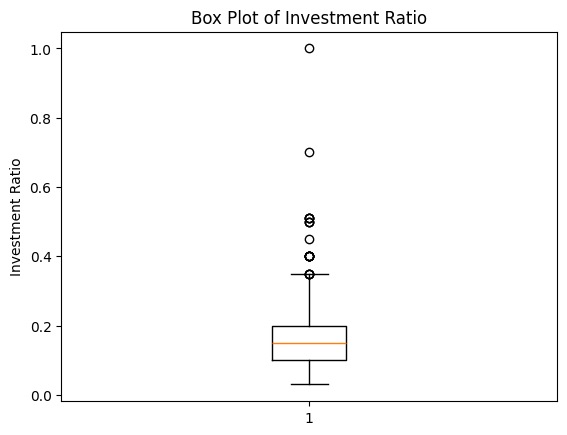

In [52]:
plt.boxplot(df['investment_ratio'])

plt.title("Box Plot of Investment Ratio")

plt.ylabel("Investment Ratio")

plt.show()

## DEAL DISTRIBUTION

In [50]:
print(df.shape)

(495, 20)


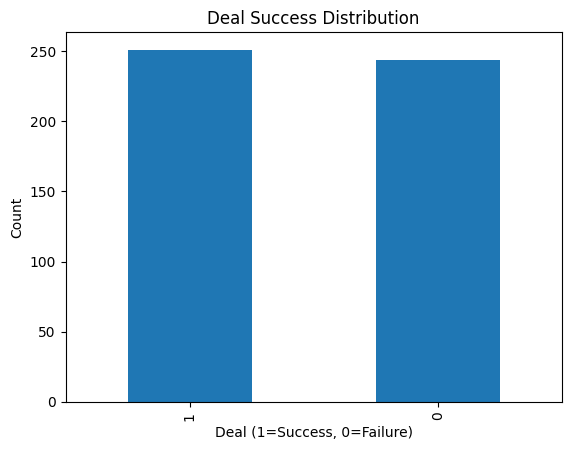

In [47]:
# Reload dataset

df = pd.read_csv("15_Investment Analytics.csv")


# Clean deal column

df['deal'] = df['deal'].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})


# Drop only necessary nulls

df = df.dropna(subset=['deal', 'askedfor', 'valuation'])


# Now plot

df['deal'].value_counts().plot(kind='bar')

plt.title("Deal Success Distribution")

plt.xlabel("Deal (1=Success, 0=Failure)")

plt.ylabel("Count")

plt.show()

C:\Users\GauravMishra\AppData\Local\Temp\ipykernel_13736\2247520437.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([success, failure], labels=['Success', 'Failure'])


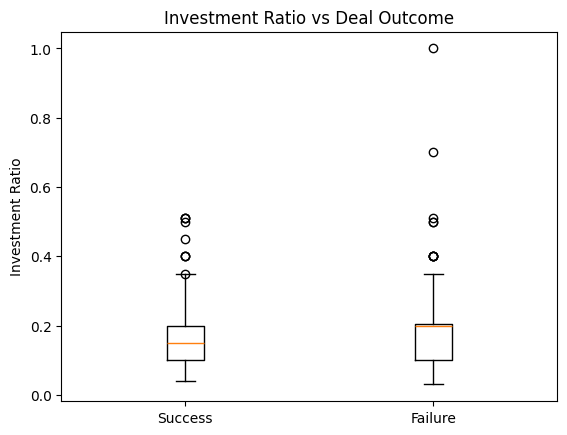

In [51]:
success = df[df['deal'] == 1]['investment_ratio']
failure = df[df['deal'] == 0]['investment_ratio']
 
plt.boxplot([success, failure], labels=['Success', 'Failure'])
 
plt.title("Investment Ratio vs Deal Outcome")
plt.ylabel("Investment Ratio")
plt.show()

## CATEGORY VS SUCCESS
#### i grouped data by category to check which idustry have higher success rate

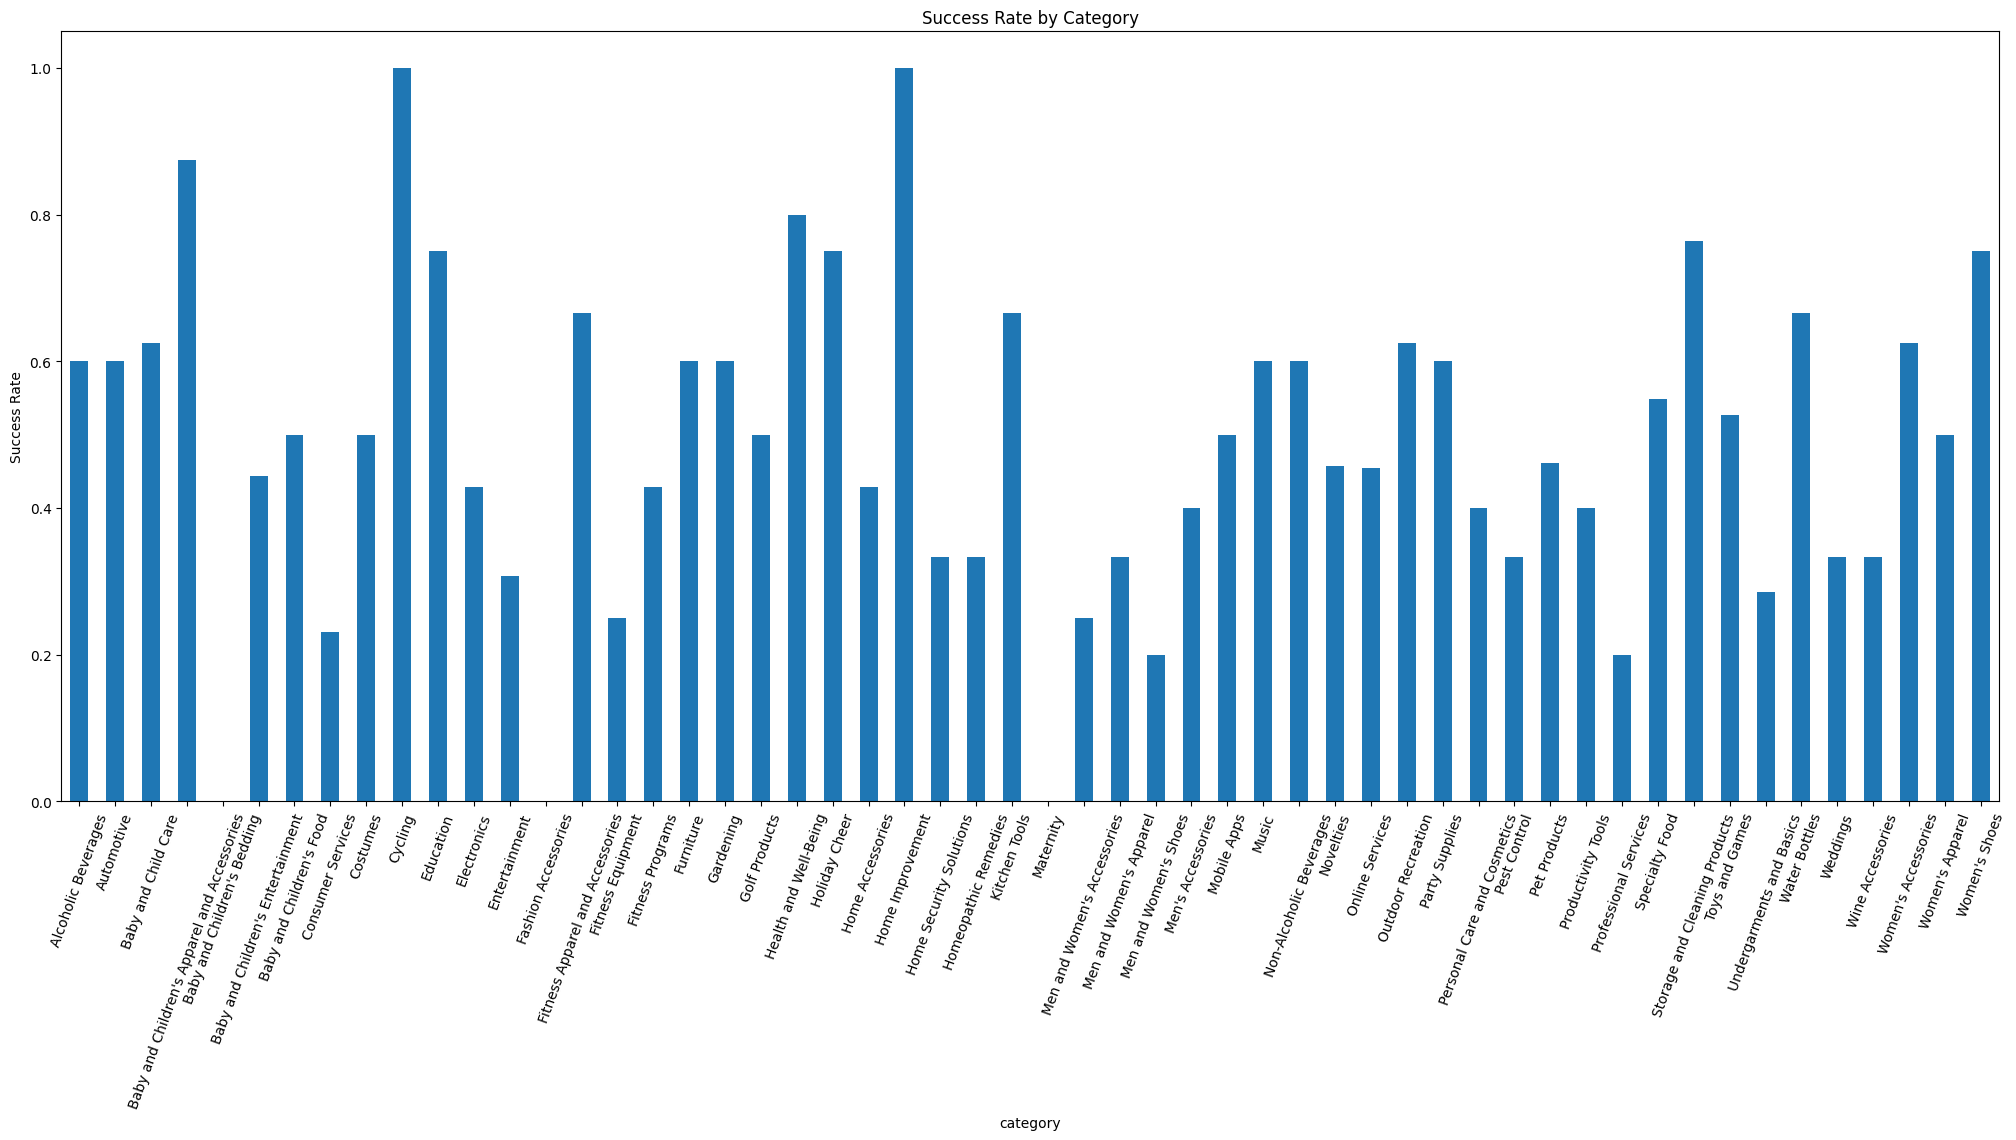

In [ ]:
category_success = df.groupby('category')['deal'].mean()


category_success.plot(kind='bar', figsize=(25,10))


plt.title("Success Rate by Category")

plt.ylabel("Success Rate")

plt.xticks(rotation=70)

plt.show()

### VALUATION VS DEAL
##### i plotted valuation vs deal outcome and abserved that higher valuation does not always guaranteed funding

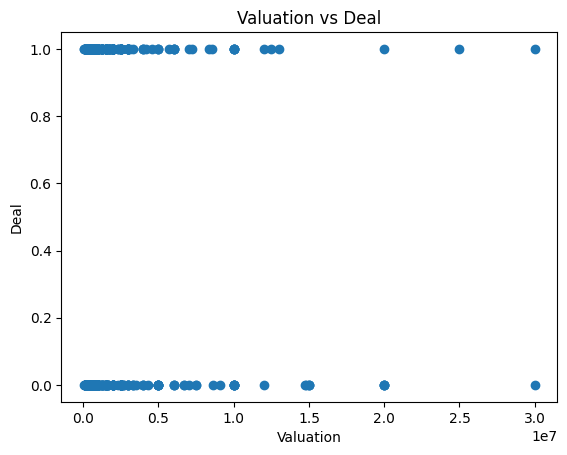

In [ ]:
plt.scatter(df['valuation'], df['deal'])

plt.title("Valuation vs Deal")

plt.xlabel("Valuation")

plt.ylabel("Deal")

plt.show()

## INVESTMENT RATIO DISTRIBUTION
#### i analyzed how investments ratio is distributed using histograms

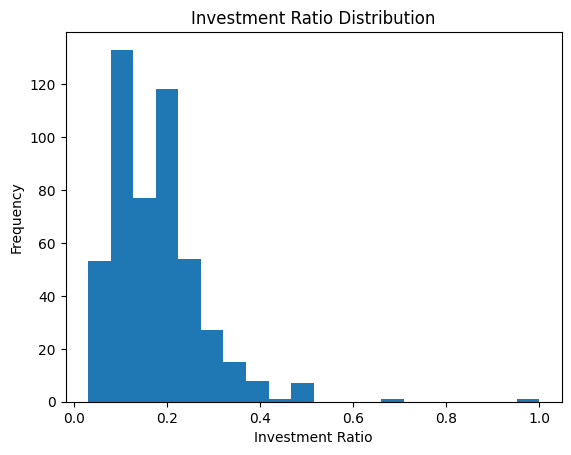

In [ ]:
plt.hist(df['investment_ratio'], bins=20)


plt.title("Investment Ratio Distribution")

plt.xlabel("Investment Ratio")

plt.ylabel("Frequency")

plt.show()

## HYPOTHESIS 1
#### Lower investments ratio increases chances of funding


In [ ]:
success_ratio = df[df['deal'] == 1]['investment_ratio'].mean()

failure_ratio = df[df['deal'] == 0]['investment_ratio'].mean()


print("Average Ratio (Success):", success_ratio)

print("Average Ratio (Failure):", failure_ratio)

Average Ratio (Success): 0.16693225980566392
Average Ratio (Failure): 0.1839959046068427


## HYPOTHESIS 2
#### category affects deal success

In [53]:
df.groupby('category')['deal'].mean().sort_values(ascending=False)

category
Cycling                                        1.000000
Home Improvement                               1.000000
Baby and Children's Apparel and Accessories    0.875000
Health and Well-Being                          0.800000
Storage and Cleaning Products                  0.764706
Holiday Cheer                                  0.750000
Education                                      0.750000
Women's Shoes                                  0.750000
Kitchen Tools                                  0.666667
Water Bottles                                  0.666667
Fitness Apparel and Accessories                0.666667
Baby and Child Care                            0.625000
Women's Accessories                            0.625000
Outdoor Recreation                             0.625000
Music                                          0.600000
Furniture                                      0.600000
Alcoholic Beverages                            0.600000
Automotive                             

In [55]:

df['all_sharks'] = df[['shark1','shark2','shark3','shark4','shark5']].astype(str).agg(','.join, axis=1)



In [57]:
shark_names = ['Barbara', 'Kevin', 'Mark', 'Lori', 'Robert', 'Daymond']


for shark in shark_names:

   success_rate = df[df['all_sharks'].str.contains(shark, case=False, na=False)]['deal'].mean()

print(shark, "success rate:", success_rate)

Daymond success rate: 0.4936061381074169


## TO FIND THE TOP CATEGORIES

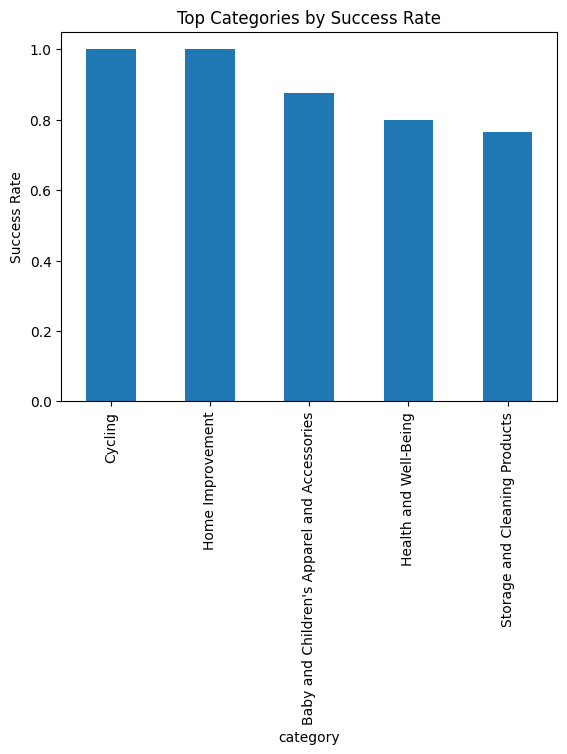

In [ ]:
top_categories = df.groupby('category')['deal'].mean().sort_values(ascending=False).head()

top_categories.plot(kind='bar')

plt.title("Top Categories by Success Rate")

plt.ylabel("Success Rate")

plt.show()

## Final Conclusion

 

- Startups with lower investment ratio have higher chances of getting funded

- Certain categories perform better than others

- Valuation alone does not guarantee deal success

- Investor (shark) presence also influences deal outcomes

 

This analysis helps understand investor decision patterns.